In [1]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model

In [2]:
model_1 = load_model("../models/MobileNetV2_BiLSTM.h5")
model_2 = load_model("../models/MobileNetV2_BiLSTM_best.h5")

In [3]:
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
SEQUENCE_LENGTH = 16
DATASET_DIR = "../data/"
CLASSES_LIST = ["NonViolence", "Violence"]

In [4]:
X_test = np.load(DATASET_DIR + "ProcessedData/X_test.npy")
y_test = np.load(DATASET_DIR + "ProcessedData/y_test.npy")

In [5]:
# Generate raw probability predictions
y_pred_1_proba = model_1.predict(X_test)
y_pred_2_proba = model_2.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 202s 18s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 184s 19s/step


In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [12]:
if y_pred_1_proba.shape[1] == 2:
    y_pred_1 = np.argmax(y_pred_1_proba, axis=1)
    y_pred_2 = np.argmax(y_pred_2_proba, axis=1)
# Or if output is shape (n_samples, 1) => sigmoid
else:
    y_pred_1 = (y_pred_1_proba > 0.5).astype(int).flatten()
    y_pred_2 = (y_pred_2_proba > 0.5).astype(int).flatten()

In [14]:
y_test_labels = np.argmax(y_test, axis=1)

In [16]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    # Classification report
    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_true, y_pred, target_names=CLASSES_LIST))

    # Basic metrics
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=CLASSES_LIST, yticklabels=CLASSES_LIST)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

## First Model Evaluation


Classification Report for MobileNetV2_BiLSTM
              precision    recall  f1-score   support

 NonViolence       0.98      0.96      0.97        99
    Violence       0.96      0.98      0.97       101

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

Accuracy:  0.9700
Precision: 0.9612
Recall:    0.9802
F1 Score:  0.9706


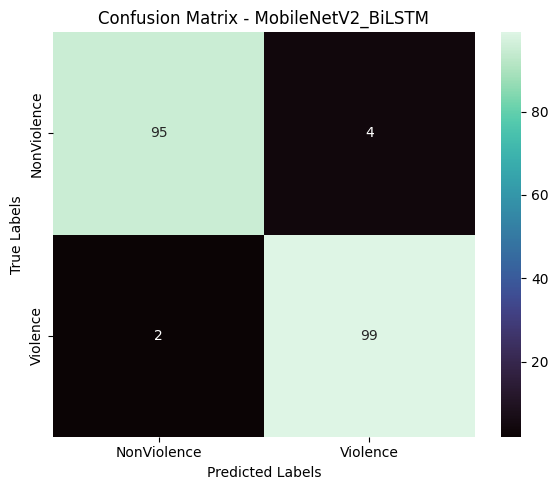

In [ ]:

evaluate_model(y_test_labels, y_pred_1, "MobileNetV2_BiLSTM")

The first model didn't use the lowest val loss, and more on maximizing the accuracy, so there might be some problems

## Best Model Evaluation


Classification Report for MobileNetV2_BiLSTM_best
              precision    recall  f1-score   support

 NonViolence       0.98      0.89      0.93        99
    Violence       0.90      0.98      0.94       101

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200

Accuracy:  0.9350
Precision: 0.9000
Recall:    0.9802
F1 Score:  0.9384


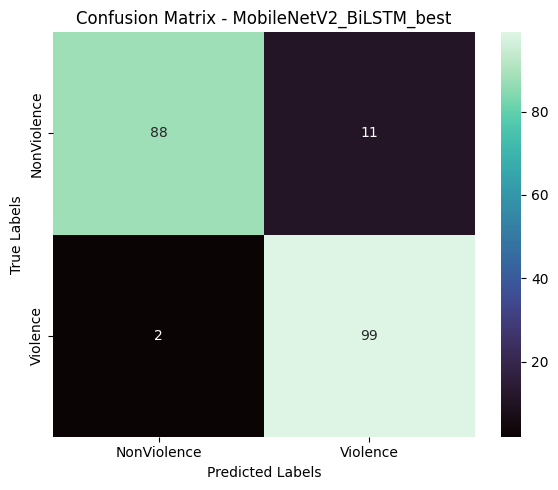

In [18]:
evaluate_model(y_test_labels, y_pred_2, "MobileNetV2_BiLSTM_best")